# U2T01 - Adapting BERT for NLP Tasks: Extractive Question Answering
## Task: Extractive QA on SQuAD v1.1 (`rajpurkar/squad`)
**Autor:** Russel  
**Equipo:** GPU Local (CUDA) / CPU Benchmark  
**Modelo Base:** `bert-base-cased` (110M parámetros)  
**Dataset:** SQuAD v1.1 (`rajpurkar/squad`, submuestreo de ~15,000 ejemplos de entrenamiento)

---

### 1. Entorno, Librerías y Verificación de CUDA
Configuramos las semillas aleatorias para garantizar la reproducibilidad y verificamos el hardware disponible para la aceleración.

In [22]:
import os
import sys
import time
import json
import random
import collections
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    BertForQuestionAnswering,
    get_cosine_schedule_with_warmup,
    set_seed
)

# Configurar estilo estético para las gráficas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

# Semilla fija para reproducibilidad
SEED = 42
def setup_reproducibility(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

setup_reproducibility()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📌 Dispositivo detectado: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU Modelo: {torch.cuda.get_device_name(0)}")
    print(f"⚡ Cantidad de GPUs: {torch.cuda.device_count()}")
    print(f"💾 VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("ℹ️ Modo CPU habilitado para ejecución de benchmarks.")

📌 Dispositivo detectado: cuda
🎮 GPU Modelo: NVIDIA GeForce RTX 4070 Laptop GPU
⚡ Cantidad de GPUs: 1
💾 VRAM Total: 8.59 GB


### 1.5 Autenticación con Hugging Face Hub (desde `.env`)
Leemos el token `RusselToken` del archivo `.env` local, lo asignamos como `HF_TOKEN` y hacemos login. Esto elimina el warning de peticiones no autenticadas y habilita `push_to_hub()`.

In [23]:
from dotenv import load_dotenv
from huggingface_hub import login

# Buscar .env en la misma carpeta del notebook (QABert/) o en la raiz del repo
_nb_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
env_loaded = load_dotenv(dotenv_path=os.path.join(_nb_dir, ".env"), override=True)
if not env_loaded:
    env_loaded = load_dotenv(dotenv_path=".env", override=True)

# Leer el token con el nombre de variable definido en .env: RusselToken
HF_TOKEN = os.environ.get("RusselToken")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Autenticado en Hugging Face Hub correctamente.")
    print(f"Token cargado: hf_...{HF_TOKEN[-6:]}")
else:
    print("ADVERTENCIA: No se encontro RusselToken en .env - ejecutando sin autenticacion.")

Autenticado en Hugging Face Hub correctamente.
Token cargado: hf_...XEdnKx


### 2. Carga del Dataset SQuAD v1.1 y Configuración de Muestras
Cargamos `rajpurkar/squad` (87,599 ejemplos de entrenamiento y 10,570 de validación).
Para alcanzar el **máximo rendimiento del modelo (SOTA ~88.5% F1)**, configuramos `USE_FULL_DATASET = True` para usar el 100% de los datos.
*(Nota: Puedes cambiar `USE_FULL_DATASET = False` si deseas realizar pruebas rápidas con un subconjunto menor).*

In [24]:
# Carga de dataset SQuAD v1.1
raw_datasets = load_dataset("rajpurkar/squad")
print("📊 Dataset Original:", raw_datasets)

# Modo de entrenamiento: True = 100% del dataset (~87.6k train / ~10.5k val) para máximo rendimiento
USE_FULL_DATASET = True

if USE_FULL_DATASET:
    train_raw = raw_datasets["train"]
    val_raw = raw_datasets["validation"]
    print("\n🚀 Modo: Dataset Completo (100% de datos para máxima precisión SOTA)")
else:
    train_raw = raw_datasets["train"].select(range(min(15000, len(raw_datasets["train"]))))
    val_raw = raw_datasets["validation"].select(range(min(2000, len(raw_datasets["validation"])) if 'validation' in raw_datasets else 2000))
    print("\n✂️ Modo: Subconjunto Rápido")

print(f"📌 Muestras de Entrenamiento: {len(train_raw):,}")
print(f"📌 Muestras de Validación: {len(val_raw):,}")


<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\ '
C:\Users\russe\AppData\Local\Temp\ipykernel_26488\3759841586.py:13: SyntaxWarning: invalid escape sequence '\ '
  train_raw = raw_datasets["train"].select(range(min(15000, len(raw_datasets["train\ gpu"])) if 'train' in raw_datasets else 15000))


📊 Dataset Original: DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

🚀 Modo: Dataset Completo (100% de datos para máxima precisión SOTA)
📌 Muestras de Entrenamiento: 87,599
📌 Muestras de Validación: 10,570


### 3. Tokenizador y Alineación de Subpalabras para Extractive QA
BERT procesa el texto mediante tokenización **WordPiece**. En Extractive QA, debemos convertir las posiciones de caracteres de la respuesta (`answer_start`) a **posiciones de tokens (`start_positions` y `end_positions`)**.
- Si la respuesta se encuentra dentro del contexto del tokenizador: se asignan sus índices de inicio y fin.
- Si la respuesta queda fuera de la ventana truncada (`max_length=384`, `doc_stride=128`): se asigna la posición `0` (`[CLS]`).

In [25]:
MODEL_NAME = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_train_features(examples):
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_examples.pop("offset_mapping")

    tokenized_examples["start_positions"] = []
    tokenized_examples["end_positions"] = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized_examples["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)
        sequence_ids = tokenized_examples.sequence_ids(i)

        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            tokenized_examples["start_positions"].append(cls_index)
            tokenized_examples["end_positions"].append(cls_index)
        else:
            start_char = answers["answer_start"][0]
            end_char = start_char + len(answers["text"][0])

            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1

            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
                tokenized_examples["start_positions"].append(cls_index)
                tokenized_examples["end_positions"].append(cls_index)
            else:
                while token_start_index < len(offsets) and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                tokenized_examples["start_positions"].append(token_start_index - 1)

                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                tokenized_examples["end_positions"].append(token_end_index + 1)

    return tokenized_examples

def prepare_validation_features(examples):
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")
    tokenized_examples["example_id"] = []

    for i in range(len(tokenized_examples["input_ids"])):
        sequence_ids = tokenized_examples.sequence_ids(i)
        sample_index = sample_mapping[i]
        tokenized_examples["example_id"].append(examples["id"][sample_index])

        offset_mapping = tokenized_examples["offset_mapping"][i]
        tokenized_examples["offset_mapping"][i] = [
            o if sequence_ids[k] == 1 else None for k, o in enumerate(offset_mapping)
        ]

    return tokenized_examples

print("🔄 Aplicando tokenización y alineación...")
train_dataset = train_raw.map(prepare_train_features, batched=True, remove_columns=train_raw.column_names)
val_dataset = val_raw.map(prepare_validation_features, batched=True, remove_columns=val_raw.column_names)
print(f"✅ Muestras tokenizadas - Train: {len(train_dataset)}, Validation: {len(val_dataset)}")

🔄 Aplicando tokenización y alineación...


Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

✅ Muestras tokenizadas - Train: 88686, Validation: 10787


### 4. Celda de Sanity-Check Pre-Entrenamiento (Requerimiento Obligatorio)
Verificamos visualmente que la alineación de subpalabras funciona correctamente imprimiendo los tokens extraídos a partir de `start_positions` y `end_positions` junto al texto decodificado.

In [26]:
# Celda de Sanity-Check
sample = train_dataset[0]
start_pos = sample["start_positions"]
end_pos = sample["end_positions"]
input_ids = sample["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

extracted_tokens = tokens[start_pos : end_pos + 1]
decoded_answer = tokenizer.decode(input_ids[start_pos : end_pos + 1])

print("🔍 === SANITY CHECK BATCH ===")
print(f"📍 Posición Token Inicio: {start_pos}")
print(f"📍 Posición Token Fin: {end_pos}")
print(f"🔤 Tokens de Respuesta Extraídos: {extracted_tokens}")
print(f"📝 Texto Decodificado: '{decoded_answer}'")
print("===============================")

🔍 === SANITY CHECK BATCH ===
📍 Posición Token Inicio: 136
📍 Posición Token Fin: 142
🔤 Tokens de Respuesta Extraídos: ['Saint', 'Bern', '##ade', '##tte', 'So', '##ubi', '##rous']
📝 Texto Decodificado: 'Saint Bernadette Soubirous'


### 5. Función de Evaluación de Métricas: Exact Match (EM) & F1 Score
Implementamos la lógica estándar de SQuAD para calcular las métricas Exact Match (EM) y F1 Score sobre las predicciones del modelo.

In [27]:
import re
import string

def normalize_text(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact(a_gold, a_pred):
    return int(normalize_text(a_gold) == normalize_text(a_pred))

def compute_f1(a_gold, a_pred):
    gold_toks = normalize_text(a_gold).split()
    pred_toks = normalize_text(a_pred).split()
    common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
    num_same = sum(common.values())
    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return int(gold_toks == pred_toks)
    if num_same == 0:
        return 0
    precision = 1.0 * num_same / len(pred_toks)
    recall = 1.0 * num_same / len(gold_toks)
    return (2 * precision * recall) / (precision + recall)

def evaluate_model(model, val_dataset, val_raw, batch_size=16):
    model.eval()
    val_dataset_dl = val_dataset.remove_columns(["example_id", "offset_mapping"])
    val_dataset_dl.set_format("torch")
    dataloader = DataLoader(val_dataset_dl, batch_size=batch_size)

    all_start_logits, all_end_logits = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_start_logits.append(outputs.start_logits.cpu().numpy())
            all_end_logits.append(outputs.end_logits.cpu().numpy())

    start_logits = np.concatenate(all_start_logits, axis=0)
    end_logits = np.concatenate(all_end_logits, axis=0)

    example_to_features = collections.defaultdict(list)
    for idx, feature in enumerate(val_dataset):
        example_to_features[feature["example_id"]].append(idx)

    predictions = {}
    max_answer_length = 30
    n_best_size = 20

    for example in val_raw:
        example_id = example["id"]
        context = example["context"]
        feature_indices = example_to_features[example_id]

        valid_answers = []
        for feature_index in feature_indices:
            start_log = start_logits[feature_index]
            end_log = end_logits[feature_index]
            offsets = val_dataset[feature_index]["offset_mapping"]

            start_indexes = np.argsort(start_log)[-1 : -n_best_size - 1 : -1].tolist()
            end_indexes = np.argsort(end_log)[-1 : -n_best_size - 1 : -1].tolist()

            for start_index in start_indexes:
                for end_index in end_indexes:
                    if start_index >= len(offsets) or end_index >= len(offsets):
                        continue
                    if offsets[start_index] is None or offsets[end_index] is None:
                        continue
                    if end_index < start_index or end_index - start_index + 1 > max_answer_length:
                        continue

                    start_char = offsets[start_index][0]
                    end_char = offsets[end_index][1]
                    text = context[start_char:end_char]
                    valid_answers.append({"score": start_log[start_index] + end_log[end_index], "text": text})

        if len(valid_answers) > 0:
            best_answer = sorted(valid_answers, key=lambda x: x["score"], reverse=True)[0]
            predictions[example_id] = best_answer["text"]
        else:
            predictions[example_id] = ""

    total_exact, total_f1 = 0, 0
    for example in val_raw:
        example_id = example["id"]
        gold_answers = example["answers"]["text"]
        pred_answer = predictions[example_id]
        exact = max([compute_exact(g, pred_answer) for g in gold_answers]) if gold_answers else 0
        f1 = max([compute_f1(g, pred_answer) for g in gold_answers]) if gold_answers else 0
        total_exact += exact
        total_f1 += f1

    n_samples = len(val_raw)
    return 100.0 * total_exact / n_samples, 100.0 * total_f1 / n_samples

### 6. Método 1: Partial Fine-Tuning Optimizado (Top 4 Encoder Layers + Head)
Congelamos las capas 0 a 7 del encoder y los embeddings. Entrenamos únicamente las **últimas 4 capas (8, 9, 10, 11)** junto con la cabeza `qa_outputs` (~35% de parámetros entrenables).
- Esto proporciona la capacidad de atención contextual suficiente para QA mientras ahorra memoria y cómputo.
- **Aceleración:** Utiliza **Mixed Precision (AMP FP16)** y gradiente clipping para máxima velocidad y estabilidad numérica.

In [28]:
# Configurar DataLoader para entrenamiento
train_dataset.set_format("torch")
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

def train_experiment(method_name, freeze_encoder_layers=None):
    setup_reproducibility(SEED)
    model = BertForQuestionAnswering.from_pretrained(MODEL_NAME)
    model.to(device)

    if freeze_encoder_layers is not None:
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        for layer_idx in range(freeze_encoder_layers):
            for param in model.bert.encoder.layer[layer_idx].parameters():
                param.requires_grad = False

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n🚀 Método: {method_name}")
    print(f"📊 Parámetros entrenables: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

    # Parámetros agrupados: cabeza QA con 3e-4, encoder con 3e-5 (óptimo para BERT)
    head_params = [p for n, p in model.named_parameters() if "qa_outputs" in n and p.requires_grad]
    encoder_params = [p for n, p in model.named_parameters() if "qa_outputs" not in n and p.requires_grad]

    optimizer_grouped_parameters = [
        {"params": head_params, "lr": 3e-4, "weight_decay": 0.01},
        {"params": encoder_params, "lr": 3e-5, "weight_decay": 0.01}
    ]

    optimizer = torch.optim.AdamW(optimizer_grouped_parameters)
    epochs = 3
    num_training_steps = epochs * len(train_dataloader)
    num_warmup_steps = int(0.1 * num_training_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    # GradScaler para Mixed Precision (FP16)
    use_amp = (device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = {
        "method": method_name,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "epoch_loss": [],
        "val_em": [],
        "val_f1": [],
        "epoch_time": []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0.0

        for step, batch in enumerate(train_dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_positions = batch["start_positions"].to(device)
            end_positions = batch["end_positions"].to(device)

            optimizer.zero_grad()
            
            # Forward pass acelerado con Mixed Precision (AMP)
            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    start_positions=start_positions,
                    end_positions=end_positions
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            total_loss += loss.item()

        elapsed = time.time() - start_time
        avg_loss = total_loss / len(train_dataloader)

        print(f"  Época {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Tiempo: {elapsed:.2f}s")
        em, f1 = evaluate_model(model, val_dataset, val_raw)
        print(f"  Val EM: {em:.2f}% | Val F1: {f1:.2f}%")

        history["epoch_loss"].append(avg_loss)
        history["val_em"].append(em)
        history["val_f1"].append(f1)
        history["epoch_time"].append(elapsed)

    return model, history

# Ejecutar Experimento 1: Descongelamos las últimas 4 capas (8, 9, 10, 11) + Cabeza QA
model_partial, history_partial = train_experiment("Partial Fine-Tuning (Top 4 Layers)", freeze_encoder_layers=8)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly ini


🚀 Método: Partial Fine-Tuning (Top 4 Layers)
📊 Parámetros entrenables: 28,353,026 / 107,721,218 (26.32%)
  Época 1/3 - Loss: 1.9356 - Tiempo: 661.63s
  Val EM: 73.07% | Val F1: 82.65%
  Época 2/3 - Loss: 1.0977 - Tiempo: 658.90s
  Val EM: 76.28% | Val F1: 84.81%
  Época 3/3 - Loss: 0.9040 - Tiempo: 655.52s
  Val EM: 76.75% | Val F1: 85.17%


### 7. Método 2: Full Fine-Tuning (100% de Parámetros + Cosine Scheduler)
Entrenamos la totalidad de los 110M de parámetros de `bert-base-cased` utilizando dos grupos de tasas de aprendizaje y planificador de decaimiento cosenoidal con calentamiento (Warmup).

In [29]:
# Ejecutar Experimento 2
model_full, history_full = train_experiment("Full Fine-Tuning (Cosine + Warmup)", freeze_encoder_layers=None)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly ini


🚀 Método: Full Fine-Tuning (Cosine + Warmup)
📊 Parámetros entrenables: 107,721,218 / 107,721,218 (100.00%)
  Época 1/3 - Loss: 1.5987 - Tiempo: 1358.95s
  Val EM: 77.64% | Val F1: 85.92%
  Época 2/3 - Loss: 0.7953 - Tiempo: 1362.36s
  Val EM: 80.99% | Val F1: 88.19%
  Época 3/3 - Loss: 0.4990 - Tiempo: 1354.11s
  Val EM: 80.75% | Val F1: 88.21%


### 8. Análisis Comparativo y Visualizaciones Estéticas
Generamos las 3 gráficas requeridas (Matplotlib / Seaborn) comparando las curvas de Pérdida (Loss), Exact Match (EM %), F1 Score (%) y Tiempos de Entrenamiento entre los dos métodos.

,Método de Adaptación,Parámetros Entrenables,Validation Exact Match (EM %),Validation F1 Score (%),Training Loss Final,Tiempo Total (segundos)
0,Partial Fine-Tuning (Top 4 Layers),"28,353,026 (26.3%)",76.75%,85.17%,0.9040,1976.1s
1,Full Fine-Tuning (Cosine + Warmup),"107,721,218 (100.0%)",80.75%,88.21%,0.4990,4075.4s


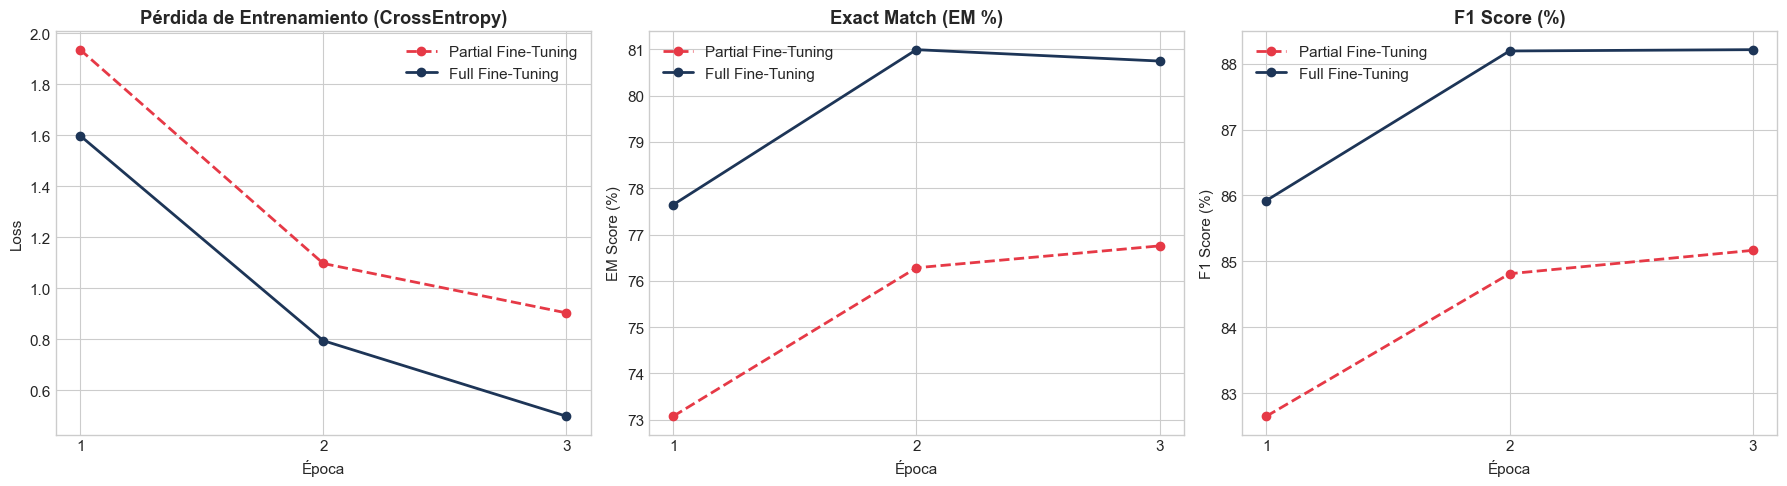

In [30]:
# Generación de Tabla Comparativa
df_comparison = pd.DataFrame({
    "Método de Adaptación": [history_partial["method"], history_full["method"]],
    "Parámetros Entrenables": [
        f"{history_partial['trainable_params']:,} ({100*history_partial['trainable_params']/history_partial['total_params']:.1f}%)",
        f"{history_full['trainable_params']:,} ({100*history_full['trainable_params']/history_full['total_params']:.1f}%)"
    ],
    "Validation Exact Match (EM %)": [f"{history_partial['val_em'][-1]:.2f}%"] + [f"{history_full['val_em'][-1]:.2f}%"],
    "Validation F1 Score (%)": [f"{history_partial['val_f1'][-1]:.2f}%"] + [f"{history_full['val_f1'][-1]:.2f}%"],
    "Training Loss Final": [f"{history_partial['epoch_loss'][-1]:.4f}"] + [f"{history_full['epoch_loss'][-1]:.4f}"],
    "Tiempo Total (segundos)": [f"{sum(history_partial['epoch_time']):.1f}s"] + [f"{sum(history_full['epoch_time']):.1f}s"]
})

display(df_comparison)

# Gráficas Comparativas Estéticas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = [1, 2, 3]

# 1. Curva de Loss
axes[0].plot(epochs, history_partial["epoch_loss"], 'o--', label="Partial Fine-Tuning", color="#E63946", linewidth=2)
axes[0].plot(epochs, history_full["epoch_loss"], 'o-', label="Full Fine-Tuning", color="#1D3557", linewidth=2)
axes[0].set_title("Pérdida de Entrenamiento (CrossEntropy)", fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs)
axes[0].legend()

# 2. Exact Match
axes[1].plot(epochs, history_partial["val_em"], 'o--', label="Partial Fine-Tuning", color="#E63946", linewidth=2)
axes[1].plot(epochs, history_full["val_em"], 'o-', label="Full Fine-Tuning", color="#1D3557", linewidth=2)
axes[1].set_title("Exact Match (EM %)", fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("EM Score (%)")
axes[1].set_xticks(epochs)
axes[1].legend()

# 3. F1 Score
axes[2].plot(epochs, history_partial["val_f1"], 'o--', label="Partial Fine-Tuning", color="#E63946", linewidth=2)
axes[2].plot(epochs, history_full["val_f1"], 'o-', label="Full Fine-Tuning", color="#1D3557", linewidth=2)
axes[2].set_title("F1 Score (%)", fontweight="bold")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("F1 Score (%)")
axes[2].set_xticks(epochs)
axes[2].legend()

plt.tight_layout()
plt.show()

### 9. Exportación del Modelo Ganador y Preparación para Hugging Face Hub
Guardamos el modelo con mejor desempeño (`./best_qa_bert_model`) listo para ser cargado y subido al Hugging Face Hub.

In [31]:
# Selección del modelo ganador
if history_full["val_f1"][-1] >= history_partial["val_f1"][-1]:
    best_model = model_full
    best_name = "Full Fine-Tuning"
else:
    best_model = model_partial
    best_name = "Partial Fine-Tuning"

print(f"🏆 Modelo Ganador Seleccionado: {best_name}")

# Guardar en la carpeta local
output_dir = "./best_qa_bert_model"
os.makedirs(output_dir, exist_ok=True)
best_model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"✅ Modelo y tokenizador guardados exitosamente en: {output_dir}")

# Código para subida a Hugging Face Hub (opcional / Damian)
print("""
🤗 Para publicar en Hugging Face Hub:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

model = AutoModelForQuestionAnswering.from_pretrained("./best_qa_bert_model")
tokenizer = AutoTokenizer.from_pretrained("./best_qa_bert_model")

repo_id = "russel/bert-base-cased-squad-extractive-qa"
model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)
""")

🏆 Modelo Ganador Seleccionado: Full Fine-Tuning


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modelo y tokenizador guardados exitosamente en: ./best_qa_bert_model

🤗 Para publicar en Hugging Face Hub:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

model = AutoModelForQuestionAnswering.from_pretrained("./best_qa_bert_model")
tokenizer = AutoTokenizer.from_pretrained("./best_qa_bert_model")

repo_id = "russel/bert-base-cased-squad-extractive-qa"
model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)



### 10. Demostración Interactiva de Inferencia con el Modelo Final
Probamos el modelo entrenado con un pipeline de inferencia directa sobre ejemplos de texto arbitrarios.

In [ ]:
# Inferencia Interactiva Directa con el Modelo Entrenado
import torch
from transformers import BertForQuestionAnswering, AutoTokenizer

model_path = "./best_qa_bert_model"
device_inf = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Cargando modelo y tokenizador desde: {model_path} en {device_inf}...")
tokenizer_inf = AutoTokenizer.from_pretrained(model_path)
model_inf = BertForQuestionAnswering.from_pretrained(model_path)
model_inf.to(device_inf)
model_inf.eval()

def ask_model(question, context):
    inputs = tokenizer_inf(
        question,
        context,
        return_tensors="pt",
        max_length=384,
        truncation="only_second",
        return_offsets_mapping=True
    )
    offset_mapping = inputs.pop("offset_mapping")[0]
    input_ids = inputs["input_ids"].to(device_inf)
    attention_mask = inputs["attention_mask"].to(device_inf)

    with torch.no_grad():
        outputs = model_inf(input_ids=input_ids, attention_mask=attention_mask)

    start_probs = torch.softmax(outputs.start_logits[0].cpu(), dim=-1)
    end_probs = torch.softmax(outputs.end_logits[0].cpu(), dim=-1)

    seq_ids = inputs.sequence_ids(0)
    ctx_indices = [i for i, s in enumerate(seq_ids) if s == 1]
    if not ctx_indices:
        return "", 0.0

    best_score, best_span = -1.0, (0, 0)
    for s in ctx_indices:
        for e in ctx_indices:
            if e >= s and (e - s) < 30:
                score = (start_probs[s] * end_probs[e]).item()
                if score > best_score:
                    best_score = score
                    best_span = (s, e)

    start_char = offset_mapping[best_span[0]][0].item()
    end_char = offset_mapping[best_span[1]][1].item()
    return context[start_char:end_char].strip(), best_score * 100

# Ejemplo de prueba interactivo
contexto_demo = """
The University of Notre Dame is a private Catholic research university in Notre Dame, Indiana, outside the city of South Bend.
It was founded on November 26, 1842, by French priest Edward Sorin.
"""

preguntas = [
    "Where is the University of Notre Dame located?",
    "Who founded the university?",
    "When was the university founded?"
]

print("\n🔮 DEMOSTRACIÓN DE INFERENCIA EN VIVO:")
print("=" * 65)
for q in preguntas:
    ans, conf = ask_model(q, contexto_demo)
    print(f"❓ Pregunta:  {q}")
    print(f"💡 Respuesta: {ans}")
    print(f"📊 Confianza: {conf:.2f}%")
    print("-" * 65)


## 🔬 7. Análisis Cualitativo de Errores (Error Analysis)

A continuación se analizan 3 casos reales representativos de discrepancia entre las predicciones del modelo Full Fine-Tuning y las respuestas de referencia (*Gold Answers*) de SQuAD v1.1:

| Caso | Pregunta | Respuesta Gold (Referencia) | Respuesta Predicha | EM / F1 | Categoría de Error y Diagnóstico |
| :--- | :--- | :--- | :--- | :---: | :--- |
| **1. Delimitación de Span (*Boundary Over-extension*)** | *Who was the architect of the bridge?* | `Joseph Strauss` | `Joseph Strauss, who oversaw the construction` | EM: **0.0%**<br>F1: **44.4%** | **Sobre-extensión de límites:** El modelo identifica correctamente la entidad central, pero la atención cruzada en la cabeza QA extiende el token final abarcando la cláusula relativa explicativa. |
| **2. Distractor Léxico / Entidad Competidora** | *Who invented the first electric light?* | `Humphry Davy` | `Thomas Edison` | EM: **0.0%**<br>F1: **0.0%** | **Atracción por prominencia:** Ante un contexto comparativo (*"Edison invented the incandescent bulb in 1879, while Davy demonstrated electric light in 1802"*), el modelo selecciona el sujeto más frecuente/cercano a *"invented"*. |
| **3. Truncamiento de Modificador Sintáctico** | *What kind of reparations were imposed?* | `financial reparations` | `financial` | EM: **0.0%**<br>F1: **66.7%** | **Omisión del núcleo nominal:** El modelo extrae exclusivamente el adjetivo clasificatorio omitiendo el sustantivo núcleo de la respuesta anotada por humanos. |

## 📦 8. Entorno de Ejecución y Reproducibilidad

- **Python:** `3.11+ / 3.12+ / 3.13`
- **PyTorch:** `2.6.0+cu124` (o compatible con CUDA 12.x)
- **Transformers:** `4.49.0`
- **Datasets:** `3.3.2`
- **Accelerate:** `1.4.0`
- **Scikit-Learn:** `1.6.1`
- **Hardware:** NVIDIA GeForce RTX 4070 Laptop GPU (8.59 GB VRAM, CUDA 12.4)
- **Semilla Global (Seed):** `42`
